In [1]:
import sys
import os
from pathlib import Path

# 1. CONFIGURACIÓN DE RUTAS (Legion Environment)
# Agregamos la carpeta raíz del módulo al sys.path para poder importar fn01 y fn02
notebook_path = Path(os.getcwd())
module_root = notebook_path.parent
if str(module_root) not in sys.path:
    sys.path.append(str(module_root))

# 2. IMPORTACIÓN DE TU EXECUTOR
# Importamos run_executor y el esquema de nombres
import fn02_executor
from fn01_python_code import dict_output_schema

# 3. DEFINICIÓN DE ENTRADAS Y SALIDAS
# Usamos el archivo .nc que tienes en tu carpeta de pruebas
input_nc = notebook_path / "OR_ABI-L2-MCMIPF-M6_G19_s20260030000228_e20260030009547_c20260030010018.nc"
output_dir = notebook_path / "output_test_fn02_executor"

# Construimos el diccionario de rutas absolutas para el procesador
dict_output_paths = {
    key: output_dir / filename 
    for key, filename in dict_output_schema.items()
}

# 4. EJECUCIÓN DEL PROCESO FNP02
print(f"🚀 Initializing FNP02 Test for: {input_nc.name}")
print(f"📂 Output directory: {output_dir}\n")

success = fn02_executor.run_executor(
    nc_path=str(input_nc),
    dict_output=dict_output_paths,
    overwrite=True  # Forzamos para ver los resultados en el test
)

# 5. VERIFICACIÓN DE RESULTADOS
if success:
    print("\n✅ Execution Finished Successfully!")
    # Listamos los archivos creados para confirmar
    print("📁 Generated Files:")
    for f in sorted(output_dir.glob("*")):
        print(f"   - {f.name} ({round(os.path.getsize(f)/1024, 2)} KB)")
else:
    print("\n❌ Execution Failed. Check the logs above.")

🚀 Initializing FNP02 Test for: OR_ABI-L2-MCMIPF-M6_G19_s20260030000228_e20260030009547_c20260030010018.nc
📂 Output directory: /home/legion/bulk/MAIE_tesis2026/f01_code/MAIE_tesis_github/src/legion_goes/task/task03_processing/subtask01_proc_single/actions/fnp/ABI_L2_MCMIPF_SP_single_fnp01/hidden_notebooks/output_test_fn02_executor

🚀 Starting FNP Processing...

      [Step 01/10] 🛰️  Loading ABI bands... Done.
      [Step 02/10] 🖼️  Saving Native True Color PNG... Done.
      [Step 03/10] 🎭  Applying Dark Pixel Mask... Done.
      [Step 04/10] ☀️  Saving Native Day-Only PNG... Done.
      [Step 05/10] 🗺️  Defining WGS84 Area Definition... Done.
      [Step 06/10] 🔄  Resampling Scene to WGS84... Done.
      [Step 07/10] 💾  Saving WGS84 PNG and GeoTIFF... Done.
      [Step 08/10] 💾  Saving WGS84 Day-Only PNG... Done.
      [Step 09/10] 📝  Generating Metadata... Done.
      [Step 10/10] 🧹  Final Memory Cleanup... Done.
Total time: 41.08s
      ✅ Preview strip (6'' per plot) generated: gall

📂 Contenido de: output_test_fn02_executor
------------------------------------------------------------
Archivo                                  |     Tamaño
------------------------------------------------------------
CRS-GoesEast_TrueColor.png               |    18.65 MB
CRS-GoesEast_TrueColor_DayOnly.png       |    18.45 MB
CRS-WGS84_TrueColor.png                  |     2.31 MB
CRS-WGS84_TrueColor.tif                  |     2.18 MB
CRS-WGS84_TrueColor_DayOnly.png          |     2.28 MB
gallery.png                              |     0.43 MB
meta.json                                |     0.00 MB
------------------------------------------------------------

🖼️ VISUALIZACIÓN DE LA GALERÍA (Tira de revisión técnica):


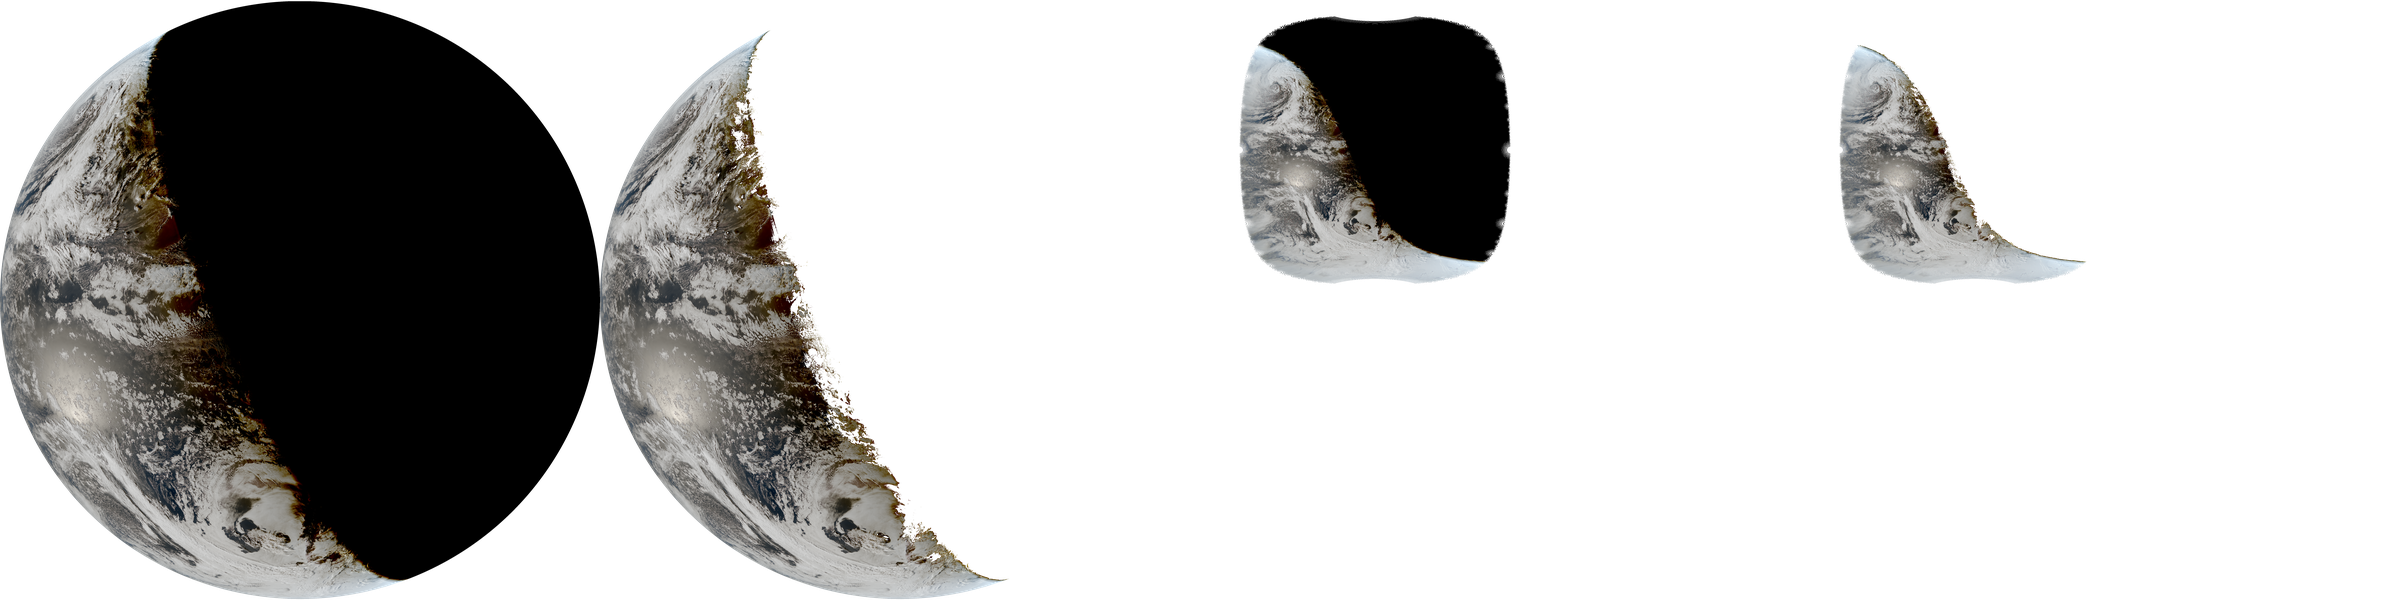

In [2]:
import os
from pathlib import Path
from IPython.display import Image, display

# 1. LISTAR CONTENIDO DE LA CARPETA
print(f"📂 Contenido de: {output_dir.name}")
print("-" * 60)
print(f"{'Archivo':<40} | {'Tamaño':>10}")
print("-" * 60)

archivos = sorted(output_dir.glob("*"))
for f in archivos:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{f.name:<40} | {size_mb:>8.2f} MB")

print("-" * 60)

# 2. VER LA GALERÍA (6 PULGADAS POR PLOT)
gallery_path = output_dir / "gallery.png"

if gallery_path.exists():
    print("\n🖼️ VISUALIZACIÓN DE LA GALERÍA (Tira de revisión técnica):")
    # Mostramos la imagen. El 'width' aquí es solo para que no se desborde 
    # visualmente en el notebook, pero no altera el archivo original.
    display(Image(filename=str(gallery_path), width=1000))
else:
    print("\n⚠️ No se encontró el archivo gallery.png")